#### 1. Dataframe basics

#### 1.1. Import pandas and reffered the package as pd + Load "telecom_churn.csv" and assign in to the variable df <span style= color:#0033cc>(3 points)</span>

In [1]:
import pandas as pd
df = pd.read_csv("telecom_churn.csv")

#### 1.2 Return the column labels/names <span style= color:#0033cc>(2 points)</span>

In [2]:
df.columns

Index(['State', 'Account length', 'Area code', 'International plan',
       'Voice mail plan', 'Number vmail messages', 'Total day minutes',
       'Total day calls', 'Total day charge', 'Total eve minutes',
       'Total eve calls', 'Total eve charge', 'Total night minutes',
       'Total night calls', 'Total night charge', 'Total intl minutes',
       'Total intl calls', 'Total intl charge', 'Customer service calls',
       'Churn'],
      dtype='str')

#### 1.3 Print the df shape <span style= color:#0033cc>(3 points)</span>

In [3]:
print(df.shape)

(3333, 20)


#### 2. What is the total day calls given by state and area code? 

#### 2.1 Group the df by state and area code (assign it to grouped variable). <span style= color:#0033cc>(5 points)</span>

In [4]:
grouped = df.groupby(['State', 'Area code'])

#### 2.2 Use agg with the desired function sum to get the final answer (assign it to telecom_agg variable).<span style= color:#0033cc>(5 points)</span>

In [5]:
telecom_agg = grouped['Total day calls'].agg('sum')
telecom_agg

State  Area code
AK     408          1342
       415          2357
       510          1255
AL     408          2524
       415          4090
                    ... 
WV     415          5474
       510          3491
WY     408          1659
       415          4205
       510          2007
Name: Total day calls, Length: 153, dtype: int64

#### 2.3 Reset the group by index <span style= color:#0033cc>(3 points)</span>

In [6]:
telecom_agg = telecom_agg.reset_index()

#### 2.4 Use head function to review the first 10 telecom_agg rows <span style= color:#0033cc>(3 points)</span>

In [7]:
telecom_agg.head(10)

,State,Area code,Total day calls
0,AK,408,1342
1,AK,415,2357
2,AK,510,1255
3,AL,408,2524
4,AL,415,4090
5,AL,510,1314
6,AR,408,1382
7,AR,415,2756
8,AR,510,1480
9,AZ,408,1452


#### 3. Users Churn rate

#### 3.1 Change "Churn" column type to an integer: <span style= color:#0033cc>(3 points)</span>

In [8]:
df['Churn'] = df['Churn'].astype(int)

#### 3.2 what is the users "churn rate" in our dataframe? <span style= color:#0033cc>(5 points)</span>
Hint: the churn rate formula can be calculated as the "number of churned" divided by the "total number of customers".

In [9]:
churn_rate = df['Churn'].mean()
print(churn_rate)

0.14491449144914492


#### 3.3  How the charn rate can affect on the company? <span style= color:#0033cc>(3 points)</span>

it tells how meny customers left in presents and can hurt the compeny

#### 3.4 How much time (on average) do churned users spend on the phone during daytime? <span style= color:#0033cc>(5 points)</span>
Hint: filter churn column when the value of churn equal to 1

In [10]:
df[df['Churn'] == 1]['Total day minutes'].mean()

np.float64(206.91407867494823)

#### 3.5 What is the maximum length of international calls among loyal users who do not have an international plan? ('International plan' == 'No') <span style= color:#0033cc>(5 points)</span>
Hint: 2 filters conditions,churn equal to 0 and international plan equal to no

In [11]:
df[(df['Churn'] == 0) & (df['International plan'] == 'No')]['Total intl minutes'].max()

np.float64(18.9)

#### 4. Select top 3 international plan subscribers and non subscribers with the most intl calls

#### 4.1. Build a function top which attributes df, n (for the top n) and column. In this function use sort_values to sort the values in the column specified. <span style= color:#0033cc>(10 points)</span>
Note: Do not apply the function on the whole data frame (e.i. top(df, n=3)) as the output will be the top 3 regardless of subscribers and non-subscribers.

In [12]:
def top(df, n=3, column='Total intl calls'):
    return df.sort_values(by=column, ascending=False).head(n)

#### 4.2. Group the df dataframe by 'International plan' and use apply(top) to apply this function. <span style= color:#0033cc>(5 points)</span>

In [13]:
df.groupby('International plan').apply(top, n=3, column='Total intl calls')

State  Account length  Area code Voice mail plan  \
International plan                                                         
No                 22      AZ             130        415              No   
                   982     ND              84        415             Yes   
                   377     ND              79        408              No   
Yes                3291    MI             119        510             Yes   
                   957     NV             144        415              No   
                   41      MD             135        408             Yes   

                         Number vmail messages  Total day minutes  \
International plan                                                  
No                 22                        0              183.0   
                   982                      33              159.1   
                   377                       0              205.7   
Yes                3291                     22              172.1   
                   957                       0              150.0   
                   41                       41              173.1   

                         Total day calls  Total day charge  Total eve minutes  \
International plan                                                              
No                 22                112             31.11               72.9   
                   982               106             27.05              149.8   
                   377               123             34.97              214.5   
Yes                3291              119             29.26              223.6   
                   957                69             25.50              285.9   
                   41                 85             29.43              203.9   

                         Total eve calls  Total eve charge  \
International plan                                           
No                 22                 99              6.20   
                   982               101             12.73   
                   377               108             18.23   
Yes                3291              133             19.01   
                   957                73             24.30   
                   41                107             17.33   

                         Total night minutes  Total night calls  \
International plan                                                
No                 22                  181.8                 78   
                   982                 213.4                108   
                   377                 226.1                106   
Yes                3291                150.0                 94   
                   957                 190.6                121   
                   41                  122.2                 78   

                         Total night charge  Total intl minutes  \
International plan                                                
No                 22                  8.18                 9.5   
                   982                 9.60                13.0   
                   377                10.17                 6.7   
Yes                3291                6.75                13.9   
                   957                 8.58                 9.4   
                   41                  5.50                14.6   

                         Total intl calls  Total intl charge  \
International plan                                             
No                 22                  19               2.57   
                   982                 18               3.51   
                   377                 18               1.81   
Yes                3291                20               3.75   
                   957                 15               2.54   
                   41                  15               3.94   

                         Customer service calls  Churn  
International plan                                      
No             

#### 5. pd.crosstab

#### 5.1 how the observations in our sample are normalized (divide each value by the sum of the values) in the context of two variables - Churn and Voice mail plan. To do so, build a contingency table using the crosstab method. <span style= color:#0033cc>(6 points)</span>
Hint: To normalize using all values, simply set normalize=True

In [14]:
pd.crosstab(df['Churn'], df['Voice mail plan'], normalize=True)

Voice mail plan,No,Yes
Churn,,
0,0.602460,0.252625
1,0.120912,0.024002


#### 5.2 What is the conclustion of most of users regarding voice mail usage? <span style= color:#0033cc>(4 points)</span>

כמעטט לא מנויים לתא קולי ורב אלו שנוטשים לא היה להם מנוי

#### 6. Columns calculations

#### 6.1 Add a column name 'total_charge', and get the total charge by sum all the charge columns <span style= color:#0033cc>(7 points)</span>

In [15]:
df['total_charge'] = df['Total day charge'] + df['Total eve charge'] + df['Total night charge'] + df['Total intl charge']

####  6.2 Add a column name 'Day_charge_pct', and get day charge precentage of total charge by dividing the column 'Total day charge' by the column 'total_charge'. <span style= color:#0033cc>(7 points)</span>

In [16]:
df['Day_charge_pct'] = df['Total day charge']/df['total_charge']

#### 7. Day charge percentage and state visualization

#### 7.1 Import matplotlib.pyplot and referred the package as plt <span style= color:#0033cc>(2 points)</span>

In [17]:
import matplotlib.pyplot as plt

#### 7.2 create new string list with the name 'my_color' that contains the following colors names: red,green,orange,blue,yellow <span style= color:#0033cc>(4 points)</span>

In [18]:
my_colors = ['red', 'green', 'orange', 'blue', 'yellow']

#### 7.3 Bar chart plot <span style= color:#0033cc>(10 points)</span>

1.Select first 5 rows of the dataframe (use df.iloc[]) 

2.Use <span style= color:blue>df.plot</span> function with kind='bar' and x='State' and y='Day_charge_pct' and color = my_colors to make a simple bar chart plot (of the day chart %).

3.Use <span style= color:blue>plt.xlabel("State Code")</span> and <span style= color:blue>plt.ylabel("Day Charge %")</span> to label the corresponding axes

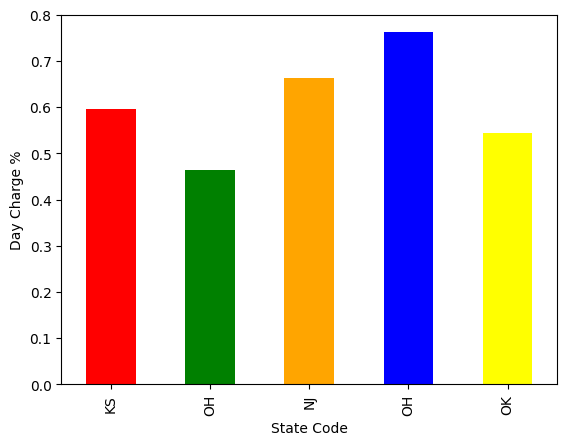

In [19]:
df_top5 = df.iloc[:5]

df_top5.plot(kind='bar', x='State', y='Day_charge_pct', color=my_colors, legend=False)

plt.xlabel("State Code")
plt.ylabel("Day Charge %")
plt.show()